In [1]:
from gwpy.timeseries import TimeSeries

t_merger = 1126259462.4
t_off = t_merger + 200
window = 4

In [2]:
from gwpy.timeseries import TimeSeries

data_H1_off = TimeSeries.fetch_open_data(
    'H1', t_off - window, t_off + window
)
data_L1_off = TimeSeries.fetch_open_data(
    'L1', t_off - window, t_off + window
)

In [3]:
wh1_off_whiten = data_H1_off.whiten().bandpass(50, 300)
wl1_off_whiten = data_L1_off.whiten().bandpass(50, 300)

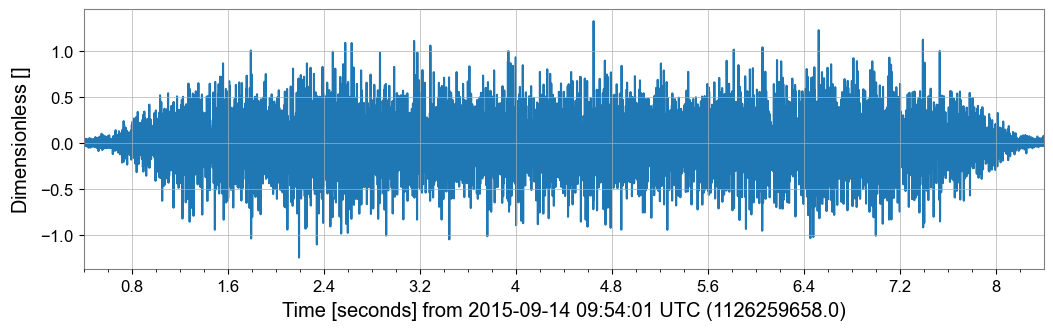

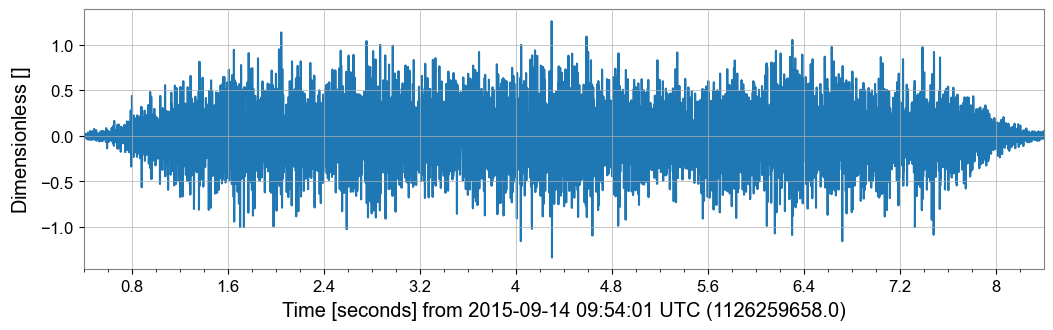

In [4]:
wh1_off_plot = wh1_off_whiten.plot()
wh1_off_plot = wl1_off_whiten.plot()

In [5]:
crop_h1_off = wh1_off_whiten.crop(t_off - 0.05, t_off + 0.05)
crop_l1_off = wl1_off_whiten.crop(t_off - 0.05, t_off + 0.05)
crop_h1_off = crop_h1_off.notch(60)
crop_l1_off = crop_l1_off.notch(60)

In [6]:
import numpy as np

corr_off = np.correlate(
    crop_h1_off.value,
    -crop_l1_off.value,
    mode='full'
)

lags = np.arange(len(corr_off)) - (len(crop_h1_off) - 1)
dt_off = lags[np.argmax(corr_off)] / data_H1_off.sample_rate.value

print(f"Off-source delay: {dt_off * 1000:.2f} ms")


Off-source delay: -0.24 ms


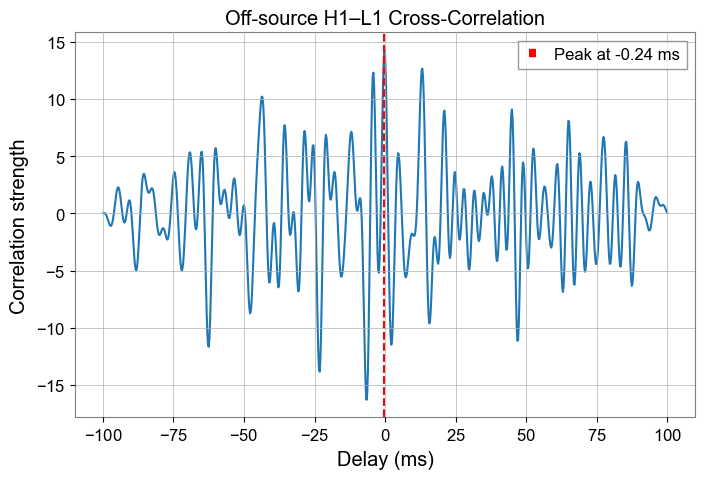

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(lags * (1000/data_H1_off.sample_rate.value), corr_off)
plt.axvline(dt_off * 1000, color='red', linestyle='--',
            label=f'Peak at {dt_off*1000:.2f} ms')
plt.xlabel('Delay (ms)')
plt.ylabel('Correlation strength')
plt.title('Off-source H1–L1 Cross-Correlation')
plt.legend()
plt.show()


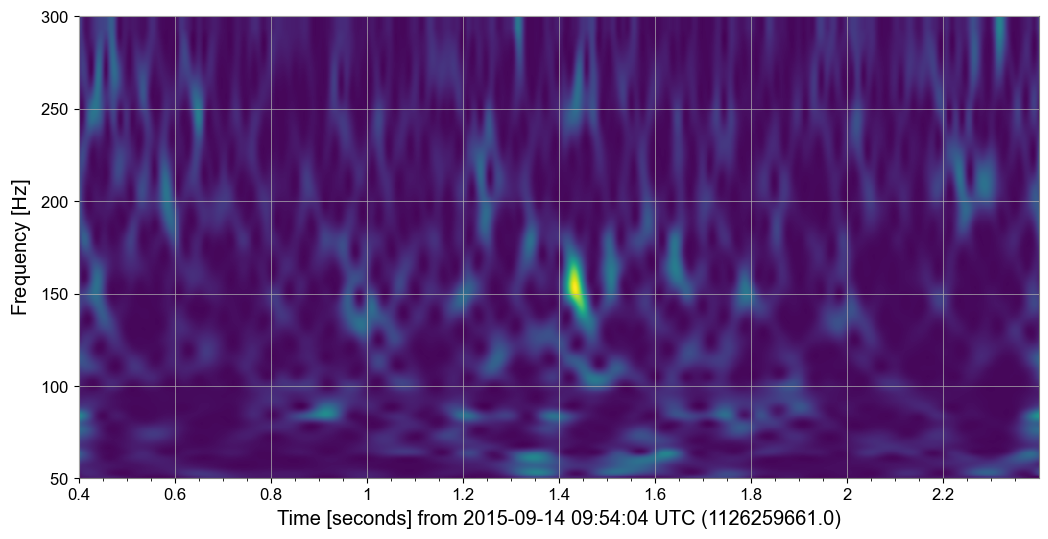

In [8]:
q_transform_data_off = wh1_off_whiten.crop(t_off - 1, t_off + 1)
q_transformation_h1_off = q_transform_data_off.q_transform(frange= (50, 300))
plot_q_transformation_off = q_transformation_h1_off.plot()